In [1]:
# Import the libraries needed to build a simple chatbot workflow
# StateGraph helps create the workflow, START and END mark entry and exit points
# TypedDict defines the state structure, and Annotated is used for message handling
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI

In [2]:
# Define the chatbot state shape
# The messages field stores the conversation history and will be updated by the workflow
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [3]:
# Create the chatbot node that processes the latest user input
# It reads the current conversation messages from state, sends them to the LLM,
# and stores the model response back into the message list
llm = ChatOpenAI()

def chat_node(state: ChatState):
    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [4]:
# Build the workflow graph for the chatbot
# Add the chat node and connect it from the start node to the end node
# This creates a simple linear workflow: start -> chat -> end
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

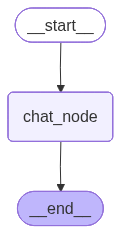

In [5]:
# Display the compiled chatbot workflow object
chatbot

In [6]:
# Create an initial conversation state with a single user message
# Then run the chatbot workflow and show the model's reply
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is New Delhi.'

In [7]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ['exit', 'quit', 'bye']:
        print("Exiting chatbot. Goodbye!")
        break

    # Update the conversation hitate with the new user message
    initial_state['messages'].append(HumanMessage(content=user_input))

    # Invoke the chatbot workflow to get the response
    response = chatbot.invoke(initial_state)

    # Print the model's reply
    model_reply = response['messages'][-1].content
    print(f"Chatbot: {model_reply}")

Chatbot: Hello! The capital of India is New Delhi. Is there anything else you would like to know?
Chatbot: Hello! How can I help you today?
Chatbot: The sum of 5 + 10 is 15.
Chatbot: The capital of India is New Delhi.
Chatbot: The capital of India is New Delhi.
Exiting chatbot. Goodbye!


In [9]:
# the chatbot is now running in a loop but cannot memorize previous
# interactions because the state is not being updated correctly. 

# so we can use  memory saver
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph =StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

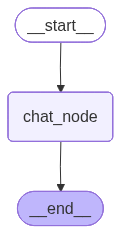

In [10]:
chatbot

In [12]:
thread_id = '1'
while True:
    user_input = input("You: ")
    if user_input.lower() in ['exit', 'quit', 'bye']:
        print("Exiting chatbot. Goodbye!")
        break

    config ={'configurable': {'thread_id': thread_id}}
    # Update the conversation hitate with the new user message
    initial_state['messages'].append(HumanMessage(content=user_input))

    # Invoke the chatbot workflow to get the response
    response = chatbot.invoke({'messages':[HumanMessage(content=user_input)]}, config=config)

    # Print the model's reply
    model_reply = response['messages'][-1].content
    print(f"Chatbot: {model_reply}")

Chatbot: Hello Shahil, nice to meet you! How can I help you today?
Chatbot: Your name is Shahil, as you mentioned earlier. How can I assist you, Shahil? 


Chatbot: The name Shahil is of Indian origin and means "blue diamond" or "gentle." It is a unique and beautiful name with a positive and serene connotation.
Chatbot: Is there anything else you would like to know or talk about, Shahil? Feel free to ask any questions or share anything on your mind.
Chatbot: You're welcome, Shahil! If you have any more questions or need assistance in the future, don't hesitate to ask. Have a great day!
Exiting chatbot. Goodbye!


In [13]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi i am shahil', additional_kwargs={}, response_metadata={}, id='11c0a9f8-0b34-4222-ba72-51e3c3c5d2f0'), AIMessage(content='Hello Shahil, nice to meet you! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 13, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DpC8JzYHCjrnjI2XyO5UNp5Ia2SeL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019eb175-a6c2-7680-b6e4-b58fb675bb80-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 16, 'total_tokens': 29, 'input_token_details': {'audio': 0, 